# Week 7 - Error Propagation and Thermobarometry

In previous weeks, we explored probability and orbital cycles. However, as Earth Scientists, we also need to understand the limitations of our data. Every measurement we take, whether it's an isotope ratio from a mass spectrometer or the width of a tree ring, comes with uncertainty.

When we use these uncertain measurements in an equation (for example, calculating the pressure at which a magma crystallized based on mineral chemistry), that error "propagates" through the calculation. This week, we will explore the "traditional" method of error propagation using quadrature and learn how to use the other Python packages to handle complex geochemical data.

## Setup and Package Installatiopn

Before we begin, we need to install a few specialized packages. We will use the `uncertainties` package for basic error handling and the `Thermobar` package for specialized calculations in igneous petrology.

In [294]:
# install the required packages using pip
%pip install uncertainties
%pip install Thermobar

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Import the Python packages we will need this week

As with every week, we will import `numpy`, `pandas`, and `matplotlib`. We will also import `Thermobar` (abbreviated as pt for pressure-temperature) to help us with some of the calculations.

In [295]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## If you haven't used it before, pip install the package
import Thermobar as pt


## Error propagation in Quadrature (the "tradiational" way)

When you have a function $f(x,y,...)$, the uncertainty in the result $\sigma_z$ is typically calculated using the partial derivatives of the function with respect to each variable. This is known as **error propagation in quadrature**. For example, for division and multiplication, the error is calculated as the square root of the sum of the square of the uncertainty of each variable divided by its magnitude (size), multiplied by the magnitude of the resulting variable. In other words:

If

$$ z = a/b $$

then

$$\sigma_z = z*\sqrt{(\sigma_a/a)^2 + (\sigma_b/b)^2} $$

## Exercise 1 - Manual Quadrature vs uncertainties package

Let's assume we are calculating the density ($\rho$) of a volcanic rock sample where $\rho = m/V$.

Mass ($m$): $100.0g \pm 0.5g$

Volume ($V$): $35.0cm^3 \pm 0.2cm^3$

Use the quadrature formula to calculate the uncertainty in the resulting density.

(5 points)

In [296]:
a=100
a_err=0.5 # Absolute error
b=35
b_err=0.2 # Absolute error

Z=a/b
print(f'p = {Z:.2f} g/cm$^3$')

p = 2.86 g/cm$^3$


In [297]:
sigma_z= Z * np.sqrt((a_err/a)**2 + (b_err/b)**2)

print(f'p = {Z:.2f}  +/- {sigma_z:.3f} g/cm$^3$')

print(f'Relative error = {100* (sigma_z/Z):.3f} %')

p = 2.86  +/- 0.022 g/cm$^3$
Relative error = 0.759 %


## Using the uncertainties package

While manual derivatives are useful for simple equations, they become nearly impossible for complex geochemical calculations. The `uncertainties` package allows Python to track these errors for us automatically using ufloat.

Using the same mass and volume from Exercise 1, use the `uncertainties.ufloat` function to define your variables and recalculate the density. Observe how the package handles the math for you.

(5 points)

In [298]:

from uncertainties import ufloat

# set up the varaibles, the syntax is the value, and then the error
a = ufloat(100, 0.5)  # a = 100 ± 5 # Absolute error
b = ufloat(35, 0.2)   # b = 20 ± 2 # Absolute error

# Perform the division
z = a/b

# This is the non ronuded value. 
print(f"Uncertainty: {z.std_dev:.3f}")

Uncertainty: 0.022


## Compare the approaches for another problem

In class I've been passing around a fragment of pumice and a set of scales. Let's take the mean mass we've measured and an estimate of the volume in cm$^3$. Assuming a 1% relative error on the mass of the pumice and a 10 cm$^3$ absolute error on the volume, calculate the uncertainty in the density of the pumice using both manual quadrature and the uncertainties package.

Be careful with units, remember that density is typically reported using kg/m$^3$

(20 points)


In [299]:
mass= 1 # Weight of the pumice block in kg. 
mass_err_perc=1 #1 percent error based on the stage
volume_cm3= 454.5  # Remember, balance your units out!
volume_err_cm3=10 # This is a absolute uncertainty. 

In [316]:
from uncertainties import ufloat

mass = 1.0
mass_err_perc = 1.0
mass_err_abs = mass * mass_err_perc / 100

volume_cm3 = 454.5
volume_err_cm3 = 10.0

volume_m3 = volume_cm3 * 1e-6
volume_m3_err = volume_err_cm3 * 1e-6

m = ufloat(mass, mass_err_abs)
V = ufloat(volume_m3, volume_m3_err)

density = m / V
print(density)
print(f"Density = {density.nominal_value:.1f} ± {density.std_dev:.1f} kg/m^3")

## using quadrature
density_m3 = mass / volume_m3
mass_err_abs = mass*mass_err_perc/100
sigma_rho= density_m3* ((mass_err_abs/mass)**2 + ((volume_err_cm3/volume_cm3)**2))**0.5
print(f'Using quadrant: {density_m3:.1f} ± {sigma_rho:.1f} kg/m^3')

(2.20+/-0.05)e+03
Density = 2200.2 ± 53.2 kg/m^3
Using quadrant: 2200.2 ± 53.2 kg/m^3


## Exercise 2 - Using Monte Carlo methods

Sometimes in geology and Earth Science we deal with incredibly 'messy' natural systems where propagating errors through quadrature can be very tedius, and challenging. One other common approach is to use a Monte Carlo methods. Essentially these act as 'brute force' methods for estimating uncertianty by running the calculation 100s to 1000s of times, on each iteration varying the input parameters within known boundary/uncertainties. In doing so, we can estimate the uncertainty in the output parameter(s).

In the remainder of the notebook we're going to first use Monte Carlo simulations to again estimate the density of a pumice fragment. After that we will use Monte Carlo simulations to estimate the uncertainty in magma storage pressures prior to eruption based on chemical data from clinopyroxene crystals. To run Monte Carlo simulations, however, we first need to learn about a couple of key terms:

**1. Prior Distributions (The Inputs):**

In your MC simulations, the prior distributions represent the initial state of your knowledge regarding the measured variables before any calculation is performed. The prior represents random distributions (usually Normal/Gaussian) generated based on your raw data and their associated measurement errors. Example from Exercise: If you measure the mass of a rock sample to be $100g \pm 0.5g$, the "prior" is the normal distribution centered at $100$ with a standard deviation of $0.5$. Role: They serve as the "input" to your model.

**2. Posterior Distribution (The Output):**

The posterior distribution represents the refined estimate of your calculated result after accounting for the uncertainties in all input variables. This is the collection of results produced by running every individual sample from your "priors" through your mathematical formula (e.g., $\rho = m/V$). For example, if we were to apply this to the calculation above the histogram of calculated density values is the "posterior distribution." Role: It tells you not just the single answer, but the range and likelihood of all possible answers.

**(20 points)** 

In the following cells:

1) Use these the `np.random.normal` function to generate a normal error distributions for volume and mass in the pumice sample above (i.e., the prior distributions).
2) Use these distributions to calculate a distribution of calculated densities for the pumice (this is known as the posterior).
3) Make a 3 part subplot (1 row, 3 columns) that shows the prior distributions and the posterior distribution in panel a-c. Add axes labels and titles.
4) Calculate the mean and standard deviation of the density. How does this compare to your estimates of uncertainty above?

In [301]:
Mass= 1 # Weight of the pumice block in kg. 
Mass_err_perc=1 #1 percent error based on the stage
volume_cm3= 454.5 * 1e-6  # Remember, balance your units out!
volume_err_cm3=10 * 1e-6 # This is a absolute uncertainty. 
N=500 


Mass_normal_dist=np.random.normal(Mass, Mass*Mass_err_perc/100, N)
Volume_normal_dist=np.random.normal(volume_m3, volume_err_cm3, N)
Density_normal_dist= Mass_normal_dist/Volume_normal_dist


np.std(Density_normal_dist)

np.float64(53.3000032326021)

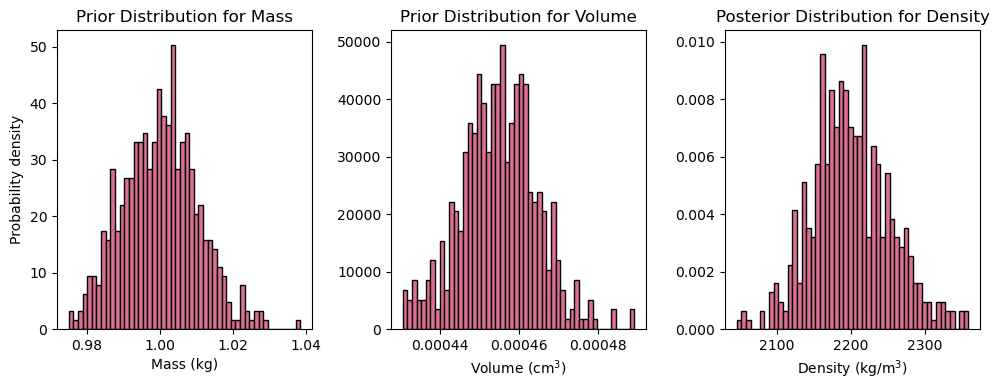

In [302]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (10,4))
c='PaleVioletRed'
ax1.hist(Mass_normal_dist, bins=50,color= c, ec='k', density=True )
ax1.set_xlabel('Mass (kg)')
ax1.set_title('Prior Distribution for Mass')

ax2.hist(Volume_normal_dist,bins=50, color= c, ec='k', density=True )
ax2.set_xlabel('Volume (cm$^{3}$)')
ax2.set_title('Prior Distribution for Volume')

ax3.hist( Density_normal_dist, bins=50, color= c, ec='k', density=True)
ax3.set_xlabel('Density (kg/m$^{3}$)')
ax3.set_title('Posterior Distribution for Density')
ax1.set_ylabel('Probability density')
fig.tight_layout()

In [303]:
print(f"Mean density:  {np.mean(Density_normal_dist):.1f} kg/m^3")
print(f"Std density:   {np.std(Density_normal_dist):.1f} kg/m^3")

Mean density:  2199.9 kg/m^3
Std density:   53.3 kg/m^3


The Monte Carlo mean density of 2200 kg/m³ and std of 53 kg/m³ is matching with the quadrature and ufloat results. This makes sense because all three methods are estimating the same thing. They will pretty much be simmilar small error and normal distubution. 

## Exercise 3 - Real data- Calculating the temperature of lava flows

1. Random Error

Random errors represent the scatter in your measurements. They are caused by the inherent limitations of instruments (like the Electron Microprobe used for the MgO measurements in the glass analyses).

Key Characteristic: If you take many measurements and average them, the random error tends to cancel out, bringing you closer to the "true" mean.

It affects Precision (how close your measurements are to each other).

2. Systematic Error

Systematic errors are consistent, repeatable offsets in one direction. They are often caused by a "bias" in the calibration or an incomplete mathematical model.

Key Characteristic: Taking more measurements does not fix systematic error. 

Tt affects Accuracy (how close your measurement is to the "true" value).

In [304]:
df_ML=pd.read_excel('data/EPS88_Glass_Data.xlsx')
df_ML.head()

,Unnamed: 0,Unnamed: 1,Sample Name,Eruption,Total_wt%,Total_Oxide%,Al2O3_Liq,CaO_Liq,FeOt_Liq,K2O_Liq,...,TiO2_Liq,Oxide % Sigma_Al2O3,Oxide % Sigma_CaO,Oxide % Sigma_FeOt,Oxide % Sigma_K2O,Oxide % Sigma_MgO,Oxide % Sigma_MnO,Oxide % Sigma_Na2O,Oxide % Sigma_SiO2,Oxide % Sigma_TiO2
0,86,NaN,M49_c55_g1,1949,97.6700,97.6700,13.7493,10.2058,10.6600,0.3752,...,2.0802,0.0503,0.0363,0.0541,0.0135,0.0387,0.0221,0.0309,0.0924,0.0293
1,87,NaN,M49_c55_g2,1949,97.6218,97.6218,13.6634,10.2227,10.8756,0.3849,...,2.0058,0.0501,0.0364,0.0545,0.0135,0.0387,0.0222,0.0311,0.0922,0.0296
2,88,NaN,M49_c55_g3,1949,98.8754,98.8754,13.8929,10.3371,10.8518,0.3545,...,2.0889,0.0505,0.0365,0.0545,0.0135,0.0392,0.0221,0.0311,0.0928,0.0294
3,89,NaN,M49_c55_g4,1949,100.5015,100.5015,14.2578,10.2994,10.7927,0.3737,...,2.1123,0.0511,0.0366,0.0542,0.0137,0.0395,0.0222,0.0309,0.0941,0.0296
4,90,NaN,M49_c55_g5,1949,99.2369,99.2369,13.9484,10.3429,10.8077,0.3768,...,2.0761,0.0506,0.0365,0.0545,0.0136,0.0393,0.0222,0.0305,0.0932,0.0296


**The temperature of lava flows can be calculated with a variety of equations, calibrated on both natural and experimental data to link lava compositions to the temperature of eruption. This is an important parameter as the temperature of a lava controls the viscosity and, in turn, the speed at which lava can move.**

Common equations include:
- Shea 2022: $T_c = 21.2 * MgO\_Liq + 1017$
- Helz 1987: $T_c = 20.1 * MgO\_Liq + 1014$
- Montrieth 1995: $T_c = 23.0 * MgO\_Liq + 1012$ 


**(10 points)** Calculate temperatures with each equation, and plot temperature against MgO (use one plot to display the results from all equations). What type of error does the choice of model count as?

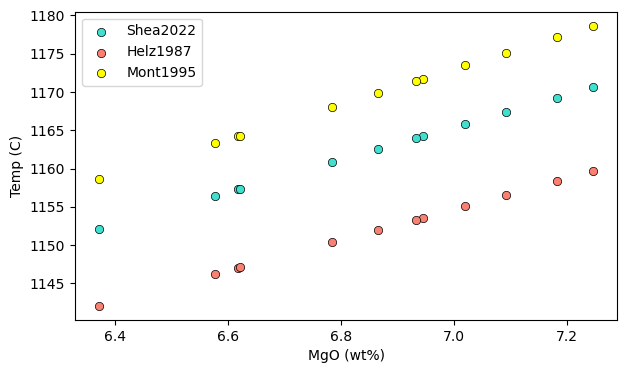

In [305]:
Shea2022 = 21.2* df_ML['MgO_Liq'] + 1017
Helz1987 = 20.1* df_ML['MgO_Liq'] + 1014
Mont1995 = 23.0* df_ML['MgO_Liq'] + 1012

fig, (ax1) = plt.subplots(1, 1, figsize = (7,4))

ax1.scatter(df_ML['MgO_Liq'], Shea2022,  color ='turquoise', edgecolors='k',linewidths=0.5,label ='Shea2022')
ax1.scatter(df_ML['MgO_Liq'], Helz1987, color = 'Salmon',edgecolors='k', linewidths=0.5,label ='Helz1987')
ax1.scatter(df_ML['MgO_Liq'], Mont1995,  color = 'yellow',edgecolors='k',linewidths=0.5,label ='Mont1995')
ax1.set_ylabel('Temp (C)')
ax1.set_xlabel('MgO (wt%)')
ax1.legend()

This is a systematic error. Each model Shea, Heltz and Mont produces a theire own consistent offset in one direction. This error will not be corrected by taking more measurements

**(20 points)** Now for a single equation (use the Shea equation), propagate the uncertainty in MgO. To do this we will use the following in formation:
- The uncertainty in MgO is given in the spreadsheet/DataFrame by the column Oxide % Sigma_MgO.  This is the ABSOLUTE error on the MgO concentration (which are reported as wt\%).
- Assume the error is normally distributed (i.e., we can use the same functions as used above)
- For each sample, use N=500 duplicates.

Recreate the plot that you made above (comparison of different models) and add error bars to the results from the Shea equation, showing the spread in temperatures from variability in MgO. This provides a nice comparison of analytical error vs. model error. What types of error is each (random vs. systematic)

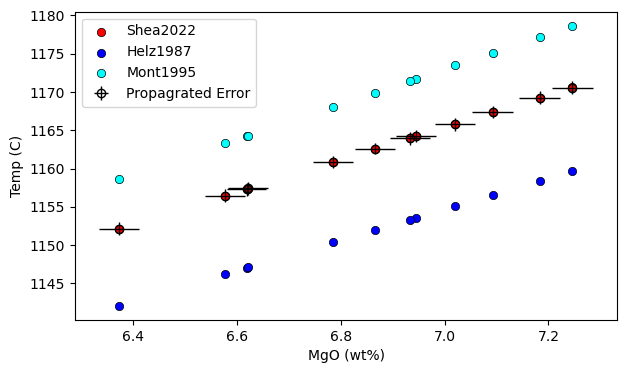

In [306]:
## Student working
N=500 # Number of duplicates. 

# Make empty arrays here that you are going to fill up.
temp_calc_errors=[] 
temp_calcs=[]


 
def shea2p22(MgO):
    return 21.2* MgO+ 1017

# Loop through each sample
for index, row in df_ML.iterrows():
    MgO_value = row['MgO_Liq']  # Extracting MgO value
    MgO_abs_err = row['Oxide % Sigma_MgO']  # Extracting MgO error

    MgO_norm = np.random.normal(MgO_value , MgO_abs_err, N)
    T_error = shea2p22(MgO_norm)

    temp_calc_errors.append(np.std(T_error))
    temp_calcs.append(np.mean(T_error))


    # Now calculate error

    # Append the error

# Now add it back on outside the dataframe for efficiency
df_ML['Temp_calc_error'] = temp_calc_errors
df_ML['Temp_calc'] = temp_calcs
    


fig, ax1 = plt.subplots(1, 1, figsize = (7,4))

ax1.scatter(df_ML['MgO_Liq'], Shea2022, color= 'red', edgecolors='k', linewidths=0.5, label='Shea2022')
ax1.scatter(df_ML['MgO_Liq'], Helz1987, color='blue', edgecolors='k', linewidths=0.5, label='Helz1987')
ax1.scatter(df_ML['MgO_Liq'], Mont1995, color='cyan', edgecolors='k', linewidths=0.5, label='Mont1995')
ax1.errorbar(df_ML['MgO_Liq'], df_ML['Temp_calc'], xerr= df_ML['Oxide % Sigma_MgO'], yerr= df_ML['Temp_calc_error'],
            fmt='o', mfc='none', mec='black',
            ecolor='black', elinewidth=1,label = 'Propagrated Error')

ax1.set_ylabel('Temp (C)')
ax1.set_xlabel('MgO (wt%)')
ax1.legend()



The MgO analytical uncertainty is a random error. This random error is caused by instrument precision and taking tha avergae of many measurments will give a value closer to the true value.

## Exercise 4 - Comparing different ways to visualize errors

A common technique in igneous petrology is to use clinopyroxene and glass compositions to calculate the pressure and temperature of magma storage prior to an eruption (more about this in lecture). In the following cell we'll load in some results of Monte Carlo simulations of clinopyroxene-liquid thermobarometry calculations. Clinopyroxene-liquid thermometry is complex, with uncertainties in about 16 different chemical components contributing to the errors in the calculated pressure and temperature. As a result, this is a good example of a case wheere Monte Carlo simualtions are useful for understanding the total uncertainty of a system.
- We are going to look at the outputs from propagating all oxides through methods to calculate pressure and temperature.
https://thermobar.readthedocs.io/en/latest/Examples/Error_propagation/Cpx_Liq_Thermobarometry_Error_prop.html
- I have recorded all the outputs - not just the mean and std in the loop - So each set of rows with the same value of Sample_ID_Liq is from a single glass

In [307]:
Out_st_noise=pd.read_excel('data/EPS88_Glass_Data.xlsx', sheet_name='MC_outputs')

## Lets look at a histogram for the first two samples

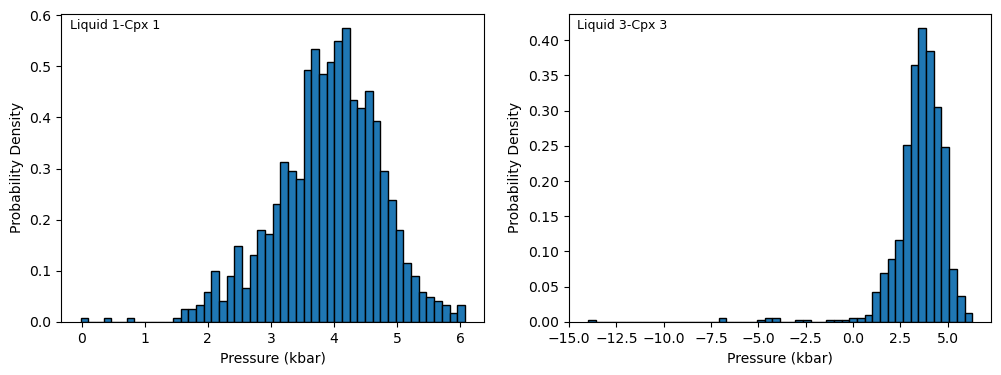

In [308]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==0, "P_kbar_calc"], bins=50, ec='k', density = True)
ax1.annotate("Liquid 1-Cpx 1", xy=(0.02, 0.95), xycoords="axes fraction", fontsize=9)
ax2.hist(Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==1, "P_kbar_calc"], bins=50, ec='k', density = True)
ax2.annotate("Liquid 3-Cpx 3", xy=(0.02, 0.95), xycoords="axes fraction", fontsize=9)

ax1.set_xlabel('Pressure (kbar)')
ax2.set_xlabel('Pressure (kbar)')
ax1.set_ylabel('Probability Density')
ax2.set_ylabel('Probability Density')
fig.savefig('Manuscript_2CpxNoises.png', dpi=300, transparent=True)

**(10 points)** Add vertical lines onto these plots showing 
- The mean value
- the mean + 1 sigma, the mean - 1 sigma. 
- The median value
- The 16th quantile (look for a numpy function that can do this)
- The 84th Quantile

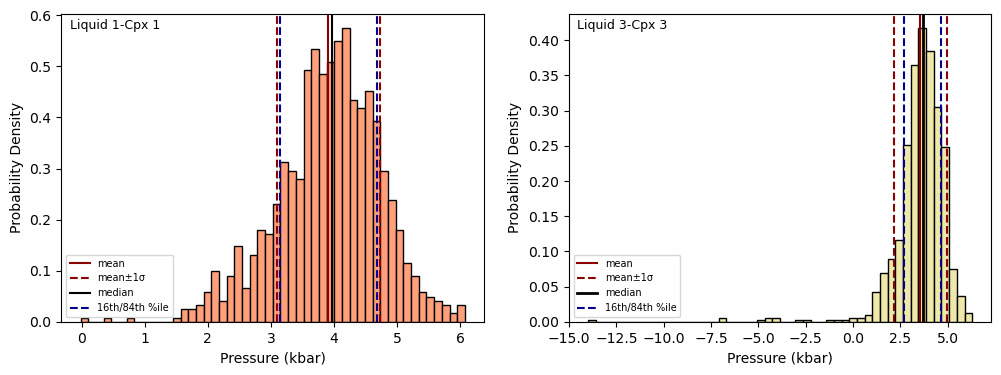

In [309]:

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(12, 4))


prob1 = Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==0, "P_kbar_calc"]
prob2 = Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==1, "P_kbar_calc"]

ax1.hist(prob1, bins=50, ec='k', density=True, color= 'LightSalmon')
ax1.axvline(np.mean(prob1), color='DarkRed', label='mean')
ax1.axvline(np.mean(prob1) + np.std(prob1),  color='DarkRed', linestyle='--', label='mean±1σ')
ax1.axvline(np.mean(prob1) - np.std(prob1),  color='DarkRed', linestyle='--')
ax1.axvline(np.median(prob1), color='k',label='median')
ax1.axvline(np.quantile(prob1, 0.16),color='DarkBlue', linestyle='--', label='16th/84th %ile')
ax1.axvline(np.quantile(prob1, 0.84), color='DarkBlue', linestyle='--')
ax1.annotate("Liquid 1-Cpx 1", xy=(0.02, 0.95), xycoords="axes fraction", fontsize=9)


ax2.hist(prob2, bins=50, ec='k', density=True, color='palegoldenrod')
ax2.axvline(np.nanmean(prob2), color='DarkRed', label='mean')
ax2.axvline(np.nanmean(prob2) + np.nanstd(prob2), color='DarkRed', linestyle='--', label='mean±1σ')
ax2.axvline(np.nanmean(prob2) - np.nanstd(prob2), color='DarkRed', linestyle='--')
ax2.axvline(np.nanmedian(prob2), color='k', linewidth=2, label='median')
ax2.axvline(np.nanquantile(prob2, 0.16), color='DarkBlue', linestyle='--', label='16th/84th %ile')
ax2.axvline(np.nanquantile(prob2, 0.84), color='DarkBlue', linestyle='--')
ax2.annotate("Liquid 3-Cpx 3", xy=(0.02, 0.95), xycoords="axes fraction", fontsize=9)

ax1.set_xlabel('Pressure (kbar)')
ax2.set_xlabel('Pressure (kbar)')
ax1.set_ylabel('Probability Density')
ax2.set_ylabel('Probability Density')

ax1.legend(fontsize=7)
ax2.legend(fontsize = 7)
fig.savefig('Manuscript_2CpxNoises.png', dpi=300, transparent=True)

**These calculations represent the result of Monte Carlo simulations, some of which return values that represent significant outliers. For this reason, do you think the mean (+/- standard deviation) or the median combined with the 16th and 84th quantile represent a better way of describing the uncertainty in the calculations?**

(10 points)

The median with 16th/84th quantiles is better here. The Monte Carlos simulations shows visible long tails in the histogram (negative skew). This negative skew will inflate the standard deviation and pull the mean away from the real center. The median is more recilient to outliers and the 16th/84th is capturing the same range as ±1σ would for a normal distribution

## Bonus - are error bars the best way to visualize errors?

The calculations we've loaded in represent Monte Carlo simulations of pressure and temperature calculations using clinopyroxene mineral data. In the cell below I calculate (and plot) the error bars in P-T space for each sample (clinopyroxene-liquid pair).

Text(0.5, 0, 'Calculated T (K)')

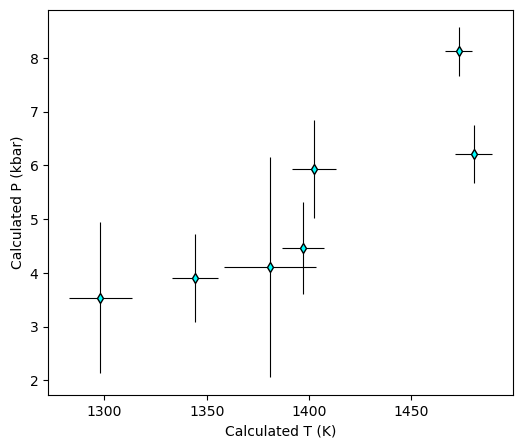

In [310]:
fig, (ax1) = plt.subplots(1, 1, figsize=(6, 5))

for sam in Out_st_noise['Sample_ID_Liq'].unique():
    Calc_PT_16=Out_st_noise.loc[Out_st_noise['Sample_ID_Liq']==sam].reset_index(drop=True)


    ax1.errorbar(np.nanmean(Calc_PT_16['T_K_calc']), 
             np.nanmean(Calc_PT_16['P_kbar_calc']), 
             xerr=np.nanstd(Calc_PT_16['T_K_calc']), 
             yerr=np.nanstd(Calc_PT_16['P_kbar_calc']), 
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k')
ax1.set_ylabel('Calculated P (kbar)')
ax1.set_xlabel('Calculated T (K)')



As an example, I've chosen one sample and will plot all individual results from the Monte Carlo simulations with the standard error bars in P and T above. Do these error bars accuartely represent the uncertainties in the data?

Text(0, 0.5, 'P (kbar)')

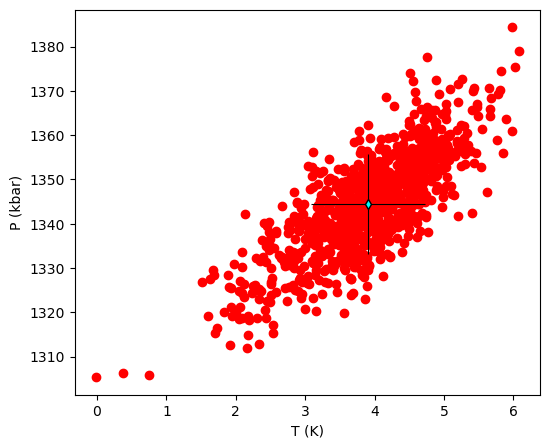

In [311]:
fig, (ax1) = plt.subplots(1, 1, figsize=(6, 5))
ax1.plot(Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==0, "P_kbar_calc"],  
         Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==0, "T_K_calc"],  
         'or')

# this is how to use the errorbar function
ax1.errorbar(np.nanmean(Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==0, "P_kbar_calc"]), 
             np.nanmean(Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==0, "T_K_calc"]), 
             xerr=np.nanstd(Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==0, "P_kbar_calc"]), 
             yerr=np.nanstd(Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==0, "T_K_calc"]), 
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k')
ax1.set_xlabel('T (K)')
ax1.set_ylabel('P (kbar)')

Now lets see another way of plotting this - and use error ellipses

Function is from here

https://matplotlib.org/stable/gallery/statistics/confidence_ellipse.html


In [312]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
def confidence_ellipse(x, y, ax, n_std=3.0, facecolor='none', **kwargs):
    """
    Create a plot of the covariance confidence ellipse of *x* and *y*.

    Parameters
    ----------
    x, y : array-like, shape (n, )
        Input data.

    ax : matplotlib.axes.Axes
        The Axes object to draw the ellipse into.

    n_std : float
        The number of standard deviations to determine the ellipse's radiuses.

    **kwargs
        Forwarded to `~matplotlib.patches.Ellipse`

    Returns
    -------
    matplotlib.patches.Ellipse
    """
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensional dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)

    # Calculating the standard deviation of x from
    # the squareroot of the variance and multiplying
    # with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)

    # calculating the standard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

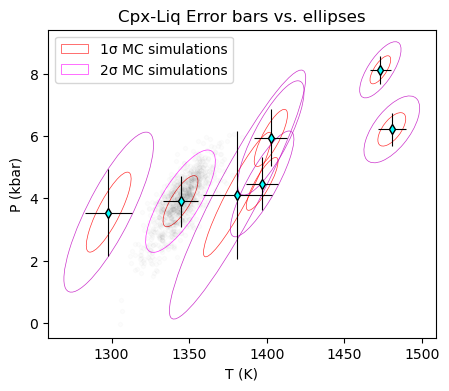

In [313]:
# 
import Thermobar as pt

fig, (ax1) = plt.subplots(1, 1, figsize=(5, 4))

# you have to plot something on the axis before you try to add the confidence intervals
for sam in Out_st_noise['Sample_ID_Liq'].unique():
    Calc_PT_16=Out_st_noise.loc[Out_st_noise['Sample_ID_Liq']==sam].reset_index(drop=True)


    ax1.errorbar(np.nanmean(Calc_PT_16['T_K_calc']), 
             np.nanmean(Calc_PT_16['P_kbar_calc']), 
             xerr=np.nanstd(Calc_PT_16['T_K_calc']), 
             yerr=np.nanstd(Calc_PT_16['P_kbar_calc']), 
             fmt='d', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k')

ax1.plot(
         Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==0, "T_K_calc"],  
         Out_st_noise.loc[Out_st_noise['Sample_ID_Liq_Num']==0, "P_kbar_calc"],  
         '.k', alpha=0.01)
    




for sam in Out_st_noise['Sample_ID_Liq'].unique():
    
    Calc_PT_16=Out_st_noise.loc[Out_st_noise['Sample_ID_Liq']==sam].reset_index(drop=True)

    y=Calc_PT_16['P_kbar_calc'].loc[Calc_PT_16['P_kbar_calc']>-10].values
    x=Calc_PT_16['T_K_calc'].loc[Calc_PT_16['P_kbar_calc']>-10].values
    if sam==Out_st_noise['Sample_ID_Liq'].unique()[0]:
        confidence_ellipse(x, y, ax1, n_std=1,
                    edgecolor='red', lw=0.5, alpha=0.8, label='1σ MC simulations')
        confidence_ellipse(x, y, ax1, n_std=2,
                    edgecolor='magenta', lw=0.5, alpha=0.8, label='2σ MC simulations')
    else:
        confidence_ellipse(x, y, ax1, n_std=1,
                    edgecolor='red', lw=0.5, alpha=0.8)
        confidence_ellipse(x, y, ax1, n_std=2,
                    edgecolor='m', lw=0.5, alpha=0.8)


        
    
    

ax1.set_xlabel('T (K)')
ax1.set_ylabel('P (kbar)')





ax1.legend()
ax1.set_title('Cpx-Liq Error bars vs. ellipses')

fig.savefig('confidence_intervals_vs_errorbars.png', dpi=200)


No, the standard error bars don’t really represent the uncertainties. They assume that the errors in P and T are independent, but in reality they are correlated. for example a higher T estimate often comes with a higher P estimate. The error bar is missing the distubution of uncertainty. The ellipse does a better job showing the correlation and the true spread